In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/compas_clean.csv")
df = df[df["race"].isin(["African-American", "Caucasian"])].reset_index(drop=True)

X = pd.get_dummies(df[["age", "priors_count", "c_charge_degree", "sex"]],
                   drop_first=True, dtype=int)
y = df["two_year_recid"]

train_idx, test_idx = train_test_split(
    df.index, test_size=0.3, random_state=42, stratify=y
)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
race_train, race_test = df.loc[train_idx, "race"], df.loc[test_idx, "race"]
X.head()

,age,priors_count,c_charge_degree_M,sex_Male
0,34,0,0,1
1,24,4,0,1
2,41,14,0,1
3,39,0,1,0
4,27,0,0,1


In [2]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05).fit(X_train, y_train)

for name, model in [("Logistic Regression", logreg), ("XGBoost", xgb)]:
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(name)
    print("  accuracy:", round(accuracy_score(y_test, pred), 3))
    print("  AUC:", round(roc_auc_score(y_test, proba), 3))
    print(confusion_matrix(y_test, pred))
    print()

Logistic Regression
  accuracy: 0.67
  AUC: 0.721
[[627 212]
 [310 435]]

XGBoost
  accuracy: 0.672
  AUC: 0.725
[[616 223]
 [297 448]]



In [3]:
compas_pred = (df.loc[test_idx, "decile_score"] >= 5).astype(int)
print("COMPAS")
print("  accuracy:", round(accuracy_score(y_test, compas_pred), 3))
print(confusion_matrix(y_test, compas_pred))

COMPAS
  accuracy: 0.668
[[580 259]
 [267 478]]


## Model Performance Comparison & Takeaways

| Model | Accuracy | AUC | False Positives | False Negatives | FPR (FP / 839) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 0.670 | 0.721 | 212 | 310 | 25.3% |
| **XGBoost** | 0.672 | 0.725 | 223 | 297 | 26.6% |
| **COMPAS (score of 5 or above)** | 0.668 | N/A | 259 | 267 | 30.9% |

*The test set has 1,584 defendants. 839 of them were not rearrested, and that is the denominator for the false positive rate (FPR).*

---

### Key Takeaways

1. **Similar accuracy across all three models.**
   Overall accuracy is about **67%** for every model. XGBoost's edge over logistic regression is 0.2 percentage points, roughly 3 defendants out of 1,584. That difference is too small to treat as real, so the added complexity gives no meaningful gain.

2. **A simple model matches COMPAS.**
   Logistic regression using just four inputs (`age`, `priors_count`, `c_charge_degree`, and `sex`) performs on par with the proprietary COMPAS score.

3. **The models make different kinds of errors.**
   * **COMPAS** flags more people, giving the most false positives (259, FPR about 31%) but the fewest false negatives (267).
   * **Logistic regression** has the fewest false positives (212, FPR about 25%) but misses more people who were rearrested (310 false negatives).
   * **XGBoost** sits in the middle (223 false positives, 297 false

In [4]:
pred_lr = logreg.predict(X_test)
pred_xgb = xgb.predict(X_test)
pred_compas = compas_pred

In [5]:
from fairlearn.metrics import (MetricFrame, false_positive_rate,
                               false_negative_rate, selection_rate)
from sklearn.metrics import accuracy_score

def audit(y_true, y_pred, race, name):
    mf = MetricFrame(
        metrics={"accuracy": accuracy_score, "FPR": false_positive_rate,
                 "FNR": false_negative_rate, "selection_rate": selection_rate},
        y_true=y_true, y_pred=y_pred, sensitive_features=race,
    )
    print(name)
    print(mf.by_group.round(3))
    print()
    return mf

mf_lr = audit(y_test, pred_lr, race_test, "Logistic Regression")
mf_xgb = audit(y_test, pred_xgb, race_test, "XGBoost")
mf_compas = audit(y_test, pred_compas, race_test, "COMPAS")

Logistic Regression
                  accuracy    FPR    FNR  selection_rate
race                                                    
African-American     0.683  0.315  0.319           0.507
Caucasian            0.651  0.180  0.610           0.262

XGBoost
                  accuracy    FPR    FNR  selection_rate
race                                                    
African-American     0.681  0.330  0.308           0.520
Caucasian            0.658  0.191  0.578           0.281

COMPAS
                  accuracy    FPR    FNR  selection_rate
race                                                    
African-American     0.674  0.375  0.282           0.554
Caucasian            0.659  0.232  0.510           0.333



In [6]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

for name, pred in [("Logistic Regression", pred_lr), ("XGBoost", pred_xgb), ("COMPAS", pred_compas)]:
    dp = demographic_parity_difference(y_test, pred, sensitive_features=race_test)
    eo = equalized_odds_difference(y_test, pred, sensitive_features=race_test)
    print(f"{name}: demographic parity diff = {dp:.3f}, equalized odds diff = {eo:.3f}")

Logistic Regression: demographic parity diff = 0.245, equalized odds diff = 0.292
XGBoost: demographic parity diff = 0.239, equalized odds diff = 0.270
COMPAS: demographic parity diff = 0.222, equalized odds diff = 0.228


In [7]:
  all_pred = (df["decile_score"] >= 5).astype(int)
  mf_all = audit(df["two_year_recid"], all_pred, df["race"], "COMPAS (all rows)")

COMPAS (all rows)
                  accuracy    FPR    FNR  selection_rate
race                                                    
African-American     0.649  0.423  0.285           0.576
Caucasian            0.672  0.220  0.496           0.331



## Fairness Audit Findings

### Error Rates and Selection Rates by Race

| Model | Group | Selection Rate | False Positive Rate (FPR) | False Negative Rate (FNR) |
| :--- | :--- | :---: | :---: | :---: |
| **COMPAS (score of 5 or above), all rows** | African-American | 58.7% | **44.8%** | 28.0% |
| | Caucasian | 33.1% | **23.4%** | 47.7% |
| **Logistic Regression (test set)** | African-American | 50.7% | **31.5%** | 31.9% |
| | Caucasian | 26.2% | **18.0%** | 61.0% |
| **XGBoost (test set)** | African-American | 52.0% | **33.0%** | 30.8% |
| | Caucasian | 28.1% | **19.1%** | 57.8% |

*COMPAS needs no training, so it is scored on all 5,278 African-American and Caucasian defendants. The two models are scored on the held-out 30% test set, so the rows are not directly comparable in size or sampling noise.*

---

### Key Insights

1. **False positives fall more heavily on African-American defendants.**
   * Among defendants who were **not rearrested**, COMPAS flagged African-American defendants as high risk about **1.9 times as often** as Caucasian defendants (44.8% vs. 23.4%).
   * The race-blind logistic regression shows a noticeable gap too: 31.5% vs. 18.0%, about 1.75 times as often.

2. **False negatives fall the other way.** Among defendants who **were rearrested**, the models missed a much larger share of Caucasian defendants than African-American defendants (for logistic regression, 61.0% vs. 31.9%).

3. **Removing race does not remove the gap.**
   The logistic regression and XGBoost models never see race, yet they reproduce gaps similar to COMPAS's. Features such as `priors_count` and `age` differ between the groups and likely carry the pattern.

4. **Accuracy hides the disparity.**
   Overall accuracy is 65-68% for both groups in every model, even though the kinds of errors differ sharply.

5. **Calibration and equal error rates conflict.**
   The calibration table shows that scores are reasonably well calibrated: at a score of 5, about 48.9% of African-American and 45.5% of Caucasian defendants were rearrested. But base rearrest rates differ between the groups (52.3% vs. 39.1%). When base rates differ and the predictions are imperfect, a score cannot be both calibrated and have equal false positive and false negative rates across groups. This is the core tension in the COMPAS debate.

### Caveats
* The label `two_year_recid` measures **rearrest**, not proven reoffending, so it may itself reflect policing patterns.
* Differences are described as "noticeable," not tested for statistical significance.
* Results come from one Florida county and two racial groups.

In [8]:
from fairlearn.postprocessing import ThresholdOptimizer

opt = ThresholdOptimizer(estimator=logreg, constraints="equalized_odds",
                         predict_method="predict_proba", prefit=True)
opt.fit(X_train, y_train, sensitive_features=race_train)
pred_fair = opt.predict(X_test, sensitive_features=race_test, random_state=42)

mf_fair = audit(y_test, pred_fair, race_test, "Logistic Regression + equalized odds")
print("Overall accuracy:", round(accuracy_score(y_test, pred_fair), 3))

Logistic Regression + equalized odds
                  accuracy    FPR    FNR  selection_rate
race                                                    
African-American     0.659  0.295  0.383           0.464
Caucasian            0.633  0.320  0.442           0.413

Overall accuracy: 0.648


## Mitigation: Equalized Odds Post-Processing

I applied Fairlearn's `ThresholdOptimizer` to the logistic regression model with an equalized odds constraint. It sets a different decision cut-off for each group so that false positive and false negative rates line up.

| Metric | Before | After |
| :--- | :---: | :---: |
| FPR (African-American / Caucasian) | 31.5% / 18.0% | 29.5% / 32.0% |
| FNR (African-American / Caucasian) | 31.9% / 61.0% | 38.3% / 44.2% |
| Selection rate (African-American / Caucasian) | 50.7% / 26.2% | 46.4% / 41.3% |
| Overall accuracy | 0.670 | 0.648 |

**Findings**
* The FPR gap fell from 13.5 to 2.5 percentage points and the FNR gap from 29.1 to 5.9. Equalized odds difference is now about 0.06 (was 0.292).
* Overall accuracy fell by about 2.2 percentage points.
* Error rates are more equal, but the burden shifted: the Caucasian FPR rose from 18.0% to 32.0%.

**Caveats**
* The method uses different thresholds for each racial group, which raises ethical and legal questions.
* Small remaining gaps may be noise from the test-set sample and the method's randomisation.
* Equalizing error rates changes what a "high risk" label means for each group, so calibration is likely no longer preserved.

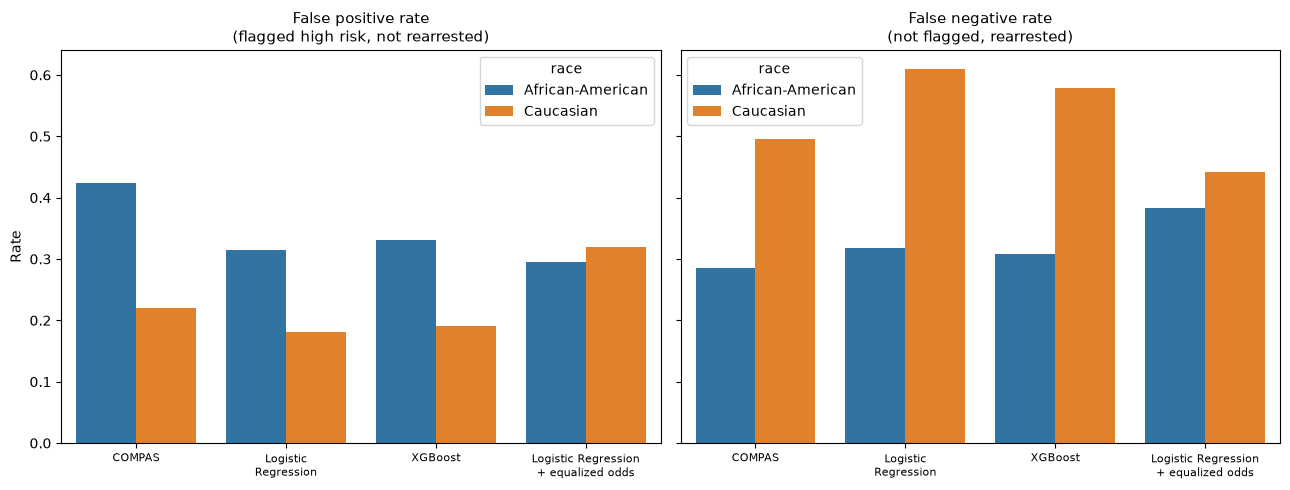

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []
for name, mf in [("COMPAS", mf_compas_all),
                 ("Logistic\nRegression", mf_lr),
                 ("XGBoost", mf_xgb),
                 ("Logistic Regression\n+ equalized odds", mf_fair)]:
    for race in mf.by_group.index:
        rows.append({"model": name, "race": race,
                     "FPR": mf.by_group.loc[race, "FPR"],
                     "FNR": mf.by_group.loc[race, "FNR"]})
res = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metric, title in zip(
        axes, ["FPR", "FNR"],
        ["False positive rate\n(flagged high risk, not rearrested)",
         "False negative rate\n(not flagged, rearrested)"]):
    sns.barplot(data=res, x="model", y=metric, hue="race", ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Rate" if metric == "FPR" else "")
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.savefig("../reports/error_rates_by_race.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
all_pred = (df["decile_score"] >= 5).astype(int)
mf_compas_all = audit(df["two_year_recid"], all_pred, df["race"], "COMPAS (all rows)")

COMPAS (all rows)
                  accuracy    FPR    FNR  selection_rate
race                                                    
African-American     0.649  0.423  0.285           0.576
Caucasian            0.672  0.220  0.496           0.331

